# 05 · Auditoría por grupos

Ejecutar todas las celdas en orden. Datos históricos y simulaciones educativas; no representan una aplicación financiera real.

In [1]:
from pathlib import Path
import sys, os
os.environ["EVIDENTLY_DO_NOT_TRACK"]="1"
base=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"_config.yml").exists())
project=base/"actividad_3/proyecto_inicial"
sys.path.insert(0,str(project/"src"))
os.environ["BANK_ROOT"]=str(project)
import numpy as np, pandas as pd
from bank_ops.data import load, partitions
from bank_ops.config import FEATURES, SEED
from bank_ops.model import pipeline, metrics
data=load(); train,validation,test=partitions(data)


In [2]:
estimator=pipeline();estimator.fit(train[FEATURES],(train.y=="yes").astype(int))
from bank_ops.monitor import fairness
probability=estimator.predict_proba(test[FEATURES])[:,1]
groups=pd.DataFrame(fairness(test,probability));display(groups)

,group,n,positives,negatives,selection_rate,tpr,fpr,reliable
0,18-29,1713,578,1135,0.060712,0.084775,0.048458,True
1,30-59,6236,1802,4434,0.057409,0.080466,0.048038,True
2,60-100,1094,476,618,0.156307,0.147059,0.163430,True


## Denominadores antes que brechas
Los grupos son pedagógicos. El indicador de volumen no sustituye intervalos de confianza.

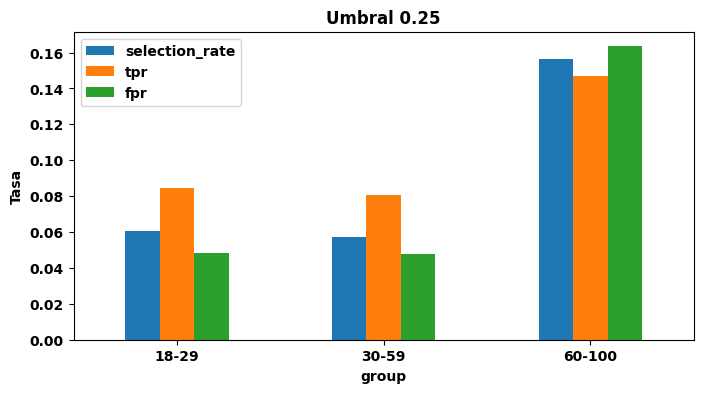

,group,n,positives,negatives,selection_rate,tpr,fpr,reliable
0,18-29,2,0.0,2.0,0.5,NaN,0.5,False
1,30-59,0,NaN,NaN,NaN,NaN,NaN,False
2,60-100,0,NaN,NaN,NaN,NaN,NaN,False


In [3]:
import matplotlib.pyplot as plt
groups.set_index("group")[["selection_rate","tpr","fpr"]].plot.bar(figsize=(8,4),rot=0)
plt.ylabel("Tasa");plt.title("Umbral 0.25");plt.show()
display(pd.DataFrame(fairness(pd.DataFrame({"age":[20,21],"y":["no","no"]}),[.1,.3])))

## Discusión
Distinguir diferencias observadas de discriminación causal. Identificar daño de falsos positivos y negativos. Test final se usa para informe, no para ajustar decisiones.

## Profundización avanzada

Experimentos de estudio opcionales. No añaden entregables ni resuelven las tareas obligatorias del proyecto inicial.

### Intervalos por grupo sobre validation
El análisis inicial de este notebook describe test como evaluación histórica del modelo fijo. La exploración adicional de umbrales e incertidumbre usa exclusivamente validation. No se seleccionan políticas con test ni se modifica el modelo servido. Los intervalos binomiales de Wilson son exploratorios bajo independencia; no corrigen selección de etiquetas o dependencia entre personas.

In [4]:
from math import sqrt
def wilson(k,n,z=1.959963984540054):
    if n<=0:return (np.nan,np.nan)
    proportion=k/n;denominator=1+z*z/n
    center=(proportion+z*z/(2*n))/denominator
    half=z*sqrt(proportion*(1-proportion)/n+z*z/(4*n*n))/denominator
    return max(0,center-half),min(1,center+half)
p_val=estimator.predict_proba(validation[FEATURES])[:,1]
age_group=pd.cut(validation.age,[17,29,59,100],labels=["18-29","30-59","60-100"])
assert age_group.notna().all(),"Hay edades fuera de la definición de grupos"
y_val=(validation.y=="yes").astype(int).to_numpy()
rows=[]
for threshold in [.10,.25]:
    for group in age_group.cat.categories:
        mask=(age_group==group).to_numpy();truth=y_val[mask];selected=p_val[mask]>=threshold
        for name,denominator_mask in [("seleccion",np.ones(len(truth),dtype=bool)),("TPR",truth==1),("FPR",truth==0)]:
            n=int(denominator_mask.sum());k=int(selected[denominator_mask].sum())
            low,high=wilson(k,n)
            rows.append({"umbral":threshold,"grupo":str(group),"metrica":name,"k":k,"n":n,
                         "tasa":k/n if n else np.nan,"inferior":low,"superior":high})
intervals=pd.DataFrame(rows);display(intervals)
assert wilson(0,0)[0]!=wilson(0,0)[0]  # NaN: denominador ausente.
assert wilson(3,5)[1]-wilson(3,5)[0]>wilson(300,500)[1]-wilson(300,500)[0]

,umbral,grupo,metrica,k,n,tasa,inferior,superior
0,0.10,18-29,seleccion,609,1258,0.484102,4.565763e-01,0.511724
1,0.10,18-29,TPR,136,194,0.701031,6.332155e-01,0.761040
2,0.10,18-29,FPR,473,1064,0.444549,4.149435e-01,0.474553
3,0.10,30-59,seleccion,1617,7504,0.215485,2.063292e-01,0.224932
4,0.10,30-59,TPR,246,771,0.319066,2.871312e-01,0.352795
5,0.10,30-59,FPR,1371,6733,0.203624,1.941755e-01,0.213410
6,0.10,60-100,seleccion,52,280,0.185714,1.445284e-01,0.235407
7,0.10,60-100,TPR,22,101,0.217822,1.484768e-01,0.307845
8,0.10,60-100,FPR,30,179,0.167598,1.199937e-01,0.229169
9,0.25,18-29,seleccion,0,1258,0.000000,0.000000e+00,0.003044


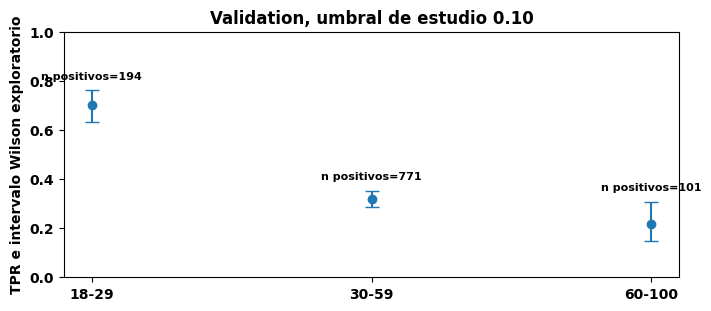

In [5]:
plot=intervals[(intervals.umbral==.10)&(intervals.metrica=="TPR")]
fig,ax=plt.subplots(figsize=(7,3),constrained_layout=True)
ax.errorbar(plot.grupo,plot.tasa,yerr=np.vstack([plot.tasa-plot.inferior,plot.superior-plot.tasa]),fmt="o",capsize=5)
ax.set(ylabel="TPR e intervalo Wilson exploratorio",ylim=(0,1),title="Validation, umbral de estudio 0.10")
for i,row in enumerate(plot.itertuples()):ax.annotate(f"n positivos={row.n}",(i,row.superior),xytext=(0,8),textcoords="offset points",ha="center",fontsize=8)
plt.show()

**Lectura:** cada intervalo corresponde a una proporción, no a la diferencia entre dos grupos. No se declara igualdad ni desigualdad poblacional mirando solo solapamiento. El umbral 0.10 se usa para estudiar sensibilidad, no como recomendación automática. Si el umbral 0.25 produce cero aciertos, sus intervalos todavía pueden tener ancho cuando existen positivos.

### Descomposición de la selección: ejemplo numérico sintético
Reconstruimos el ejemplo del capítulo: grupos con TPR igual, FPR y prevalencia diferentes. Los conteos son inventados para demostrar la identidad algebraica, no resultados del dataset.

In [6]:
toy=pd.DataFrame([{"grupo":"A","n":200,"positivos":40,"TP":24,"FP":32},
                  {"grupo":"B","n":800,"positivos":80,"TP":48,"FP":72}])
toy["prevalencia"]=toy.positivos/toy.n
toy["TPR"]=toy.TP/toy.positivos
toy["FPR"]=toy.FP/(toy.n-toy.positivos)
toy["seleccion"]=(toy.TP+toy.FP)/toy.n
toy["reconstruida"]=toy.TPR*toy.prevalencia+toy.FPR*(1-toy.prevalencia)
assert np.allclose(toy.seleccion,toy.reconstruida)
display(toy)

,grupo,n,positivos,TP,FP,prevalencia,TPR,FPR,seleccion,reconstruida
0,A,200,40,24,32,0.2,0.6,0.2,0.28,0.28
1,B,800,80,48,72,0.1,0.6,0.1,0.15,0.15


**Preguntas:** ¿qué diferencia importa para el daño que quiere evaluar?, ¿qué mecanismo de selección de etiquetas podría distorsionar la comparación?, ¿qué información falta para proponer una mitigación? No se añade Fairlearn como dependencia: se calculan explícitamente las cantidades para entender sus denominadores.